In [30]:
from sklearn.model_selection import GridSearchCV

In [31]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

In [32]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [33]:
grid_search.fit(X_train, Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [34]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 10, 'solver': 'liblinear'}


In [35]:
print("Best Cross Validation Score:", grid_search.best_score_)

Best Cross Validation Score: 0.9626373626373628


In [36]:
best_model = grid_search.best_estimator_

In [37]:
y_pred_tuned = best_model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score

tuned_accuracy = accuracy_score(Y_test, y_pred_tuned)

print("Baseline Accuracy:", accuracy)
print("Tuned Accuracy:", tuned_accuracy)

Baseline Accuracy: 0.956140350877193
Tuned Accuracy: 0.956140350877193


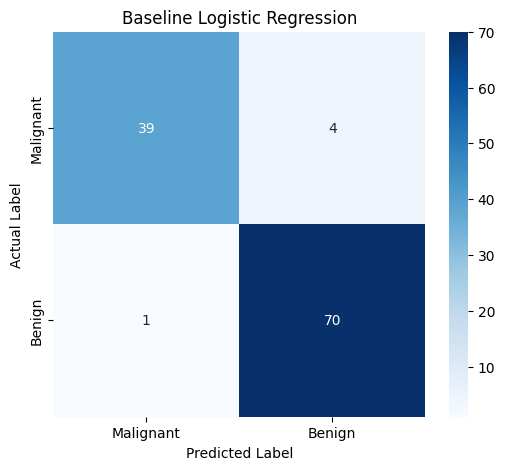

In [42]:
cm_baseline = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.title("Baseline Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

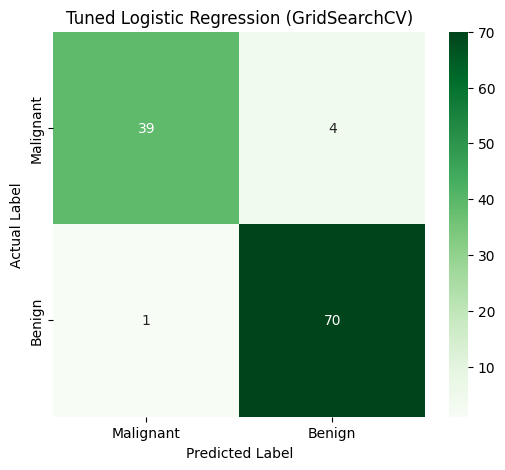

In [43]:
cm_tuned = confusion_matrix(Y_test, y_pred_tuned)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_tuned,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Malignant', 'Benign'],
    yticklabels=['Malignant', 'Benign']
)

plt.title("Tuned Logistic Regression (GridSearchCV)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()